In [6]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (303, 13)
Target Shape: (303,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (242, 13)
Testing Data: (61, 13)


In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [9]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 1 1 1 1 1 1 1 0 1]


In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8852459016393442


In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[25  4]
 [ 3 29]]


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8688524590163934


     Feature  Importance
2         cp    0.127280
7    thalach    0.116200
9    oldpeak    0.113342
11        ca    0.112550
0        age    0.105167
12      thal    0.095484
4       chol    0.079107
3   trestbps    0.074830
10     slope    0.055162
8      exang    0.051821
1        sex    0.035816
6    restecg    0.021773
5        fbs    0.011468


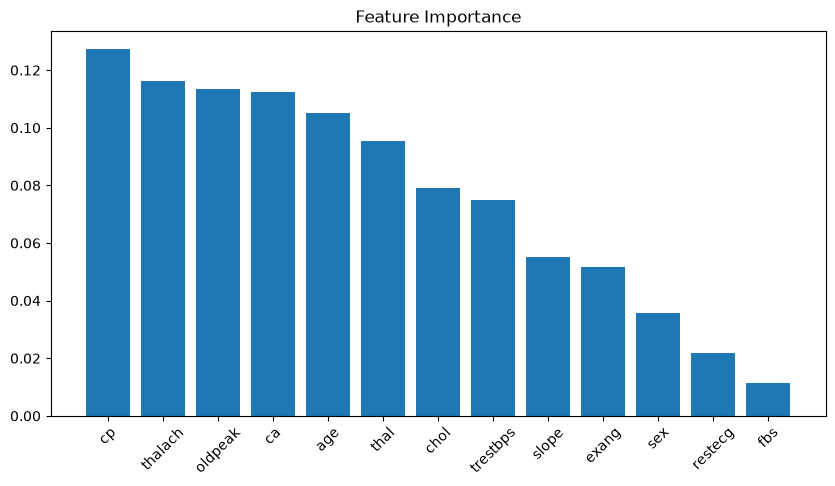

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(10,5))
plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()